In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.7 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import os
from IPython.display import Image

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
base_path = '/content/drive/MyDrive/dataset'

In [ ]:
model = YOLO('yolov8n-cls.pt')

In [ ]:
model.train(
    data=base_path,
    epochs=10,
    imgsz=224
)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/dataset, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79594052bd10>
curves: []
curves_results: []
fitness: 0.9861178696155548
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.9722357392311096, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9861178696155548}
save_dir: PosixPath('/content/runs/classify/train')
speed: {'preprocess': 0.0011909009263709213, 'inference': 14.523155693125494, 'loss': 6.079104264809795e-05, 'postprocess': 9.980788832352099e-05}
top1: 0.9722357392311096
top5: 1.0

In [ ]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv8n-cls summary (fused): 30 layers, 1,437,442 parameters, 0 gradients, 3.3 GFLOPs
train: /content/drive/MyDrive/dataset/train... found 22523 images in 2 classes ✅ 
val: /content/drive/MyDrive/dataset/val... found 10265 images in 2 classes ✅ 
test: /content/drive/MyDrive/dataset/test... found 24705 images in 2 classes ✅ 
val: Fast image access ✅ (ping: 0.5±0.1 ms, read: 4.7±2.9 MB/s, size: 9.2 KB)
val: Scanning /content/drive/MyDrive/dataset/val... 10265 images, 0 corrupt: 100% ━━━━━━━━━━━━ 10265/10265 1.5Git/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 642/642 2.2it/s 4:50
                   all      0.972          1
Speed: 0.0ms preprocess, 14.0ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val
ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object

In [ ]:
from sklearn.metrics import classification_report
import os

In [ ]:
def get_true_labels(path):
    labels = []
    class_map = {'organic':0, 'recyclable':1}

    for cls in os.listdir(path):
        for img in os.listdir(os.path.join(path, cls)):
            labels.append(class_map[cls])

    return labels

In [ ]:
def get_predictions(model, path):
    preds = []

    for cls in os.listdir(path):
        for img in os.listdir(os.path.join(path, cls)):
            img_path = os.path.join(path, cls, img)
            result = model.predict(img_path, verbose=False)
            preds.append(result[0].probs.top1)

    return preds

In [ ]:
train_path = '/content/drive/MyDrive/dataset/train'
test_path = '/content/drive/MyDrive/dataset/test'

# TEST
y_true_test = get_true_labels(test_path)
y_pred_test = get_predictions(model, test_path)

print("===== TESTING REPORT =====")
print(classification_report(
    y_true_test, y_pred_test,
    target_names=['organic','recyclable']
))

# TRAIN
y_true_train = get_true_labels(train_path)
y_pred_train = get_predictions(model, train_path)

print("===== TRAINING REPORT =====")
print(classification_report(
    y_true_train, y_pred_train,
    target_names=['organic','recyclable']
))

===== TESTING REPORT =====
              precision    recall  f1-score   support

     organic       0.98      0.98      0.98     13880
  recyclable       0.97      0.97      0.97     10825

    accuracy                           0.98     24705
   macro avg       0.98      0.98      0.98     24705
weighted avg       0.98      0.98      0.98     24705

===== TRAINING REPORT =====
              precision    recall  f1-score   support

     organic       0.99      0.98      0.98     13863
  recyclable       0.97      0.98      0.97      8660

    accuracy                           0.98     22523
   macro avg       0.98      0.98      0.98     22523
weighted avg       0.98      0.98      0.98     22523



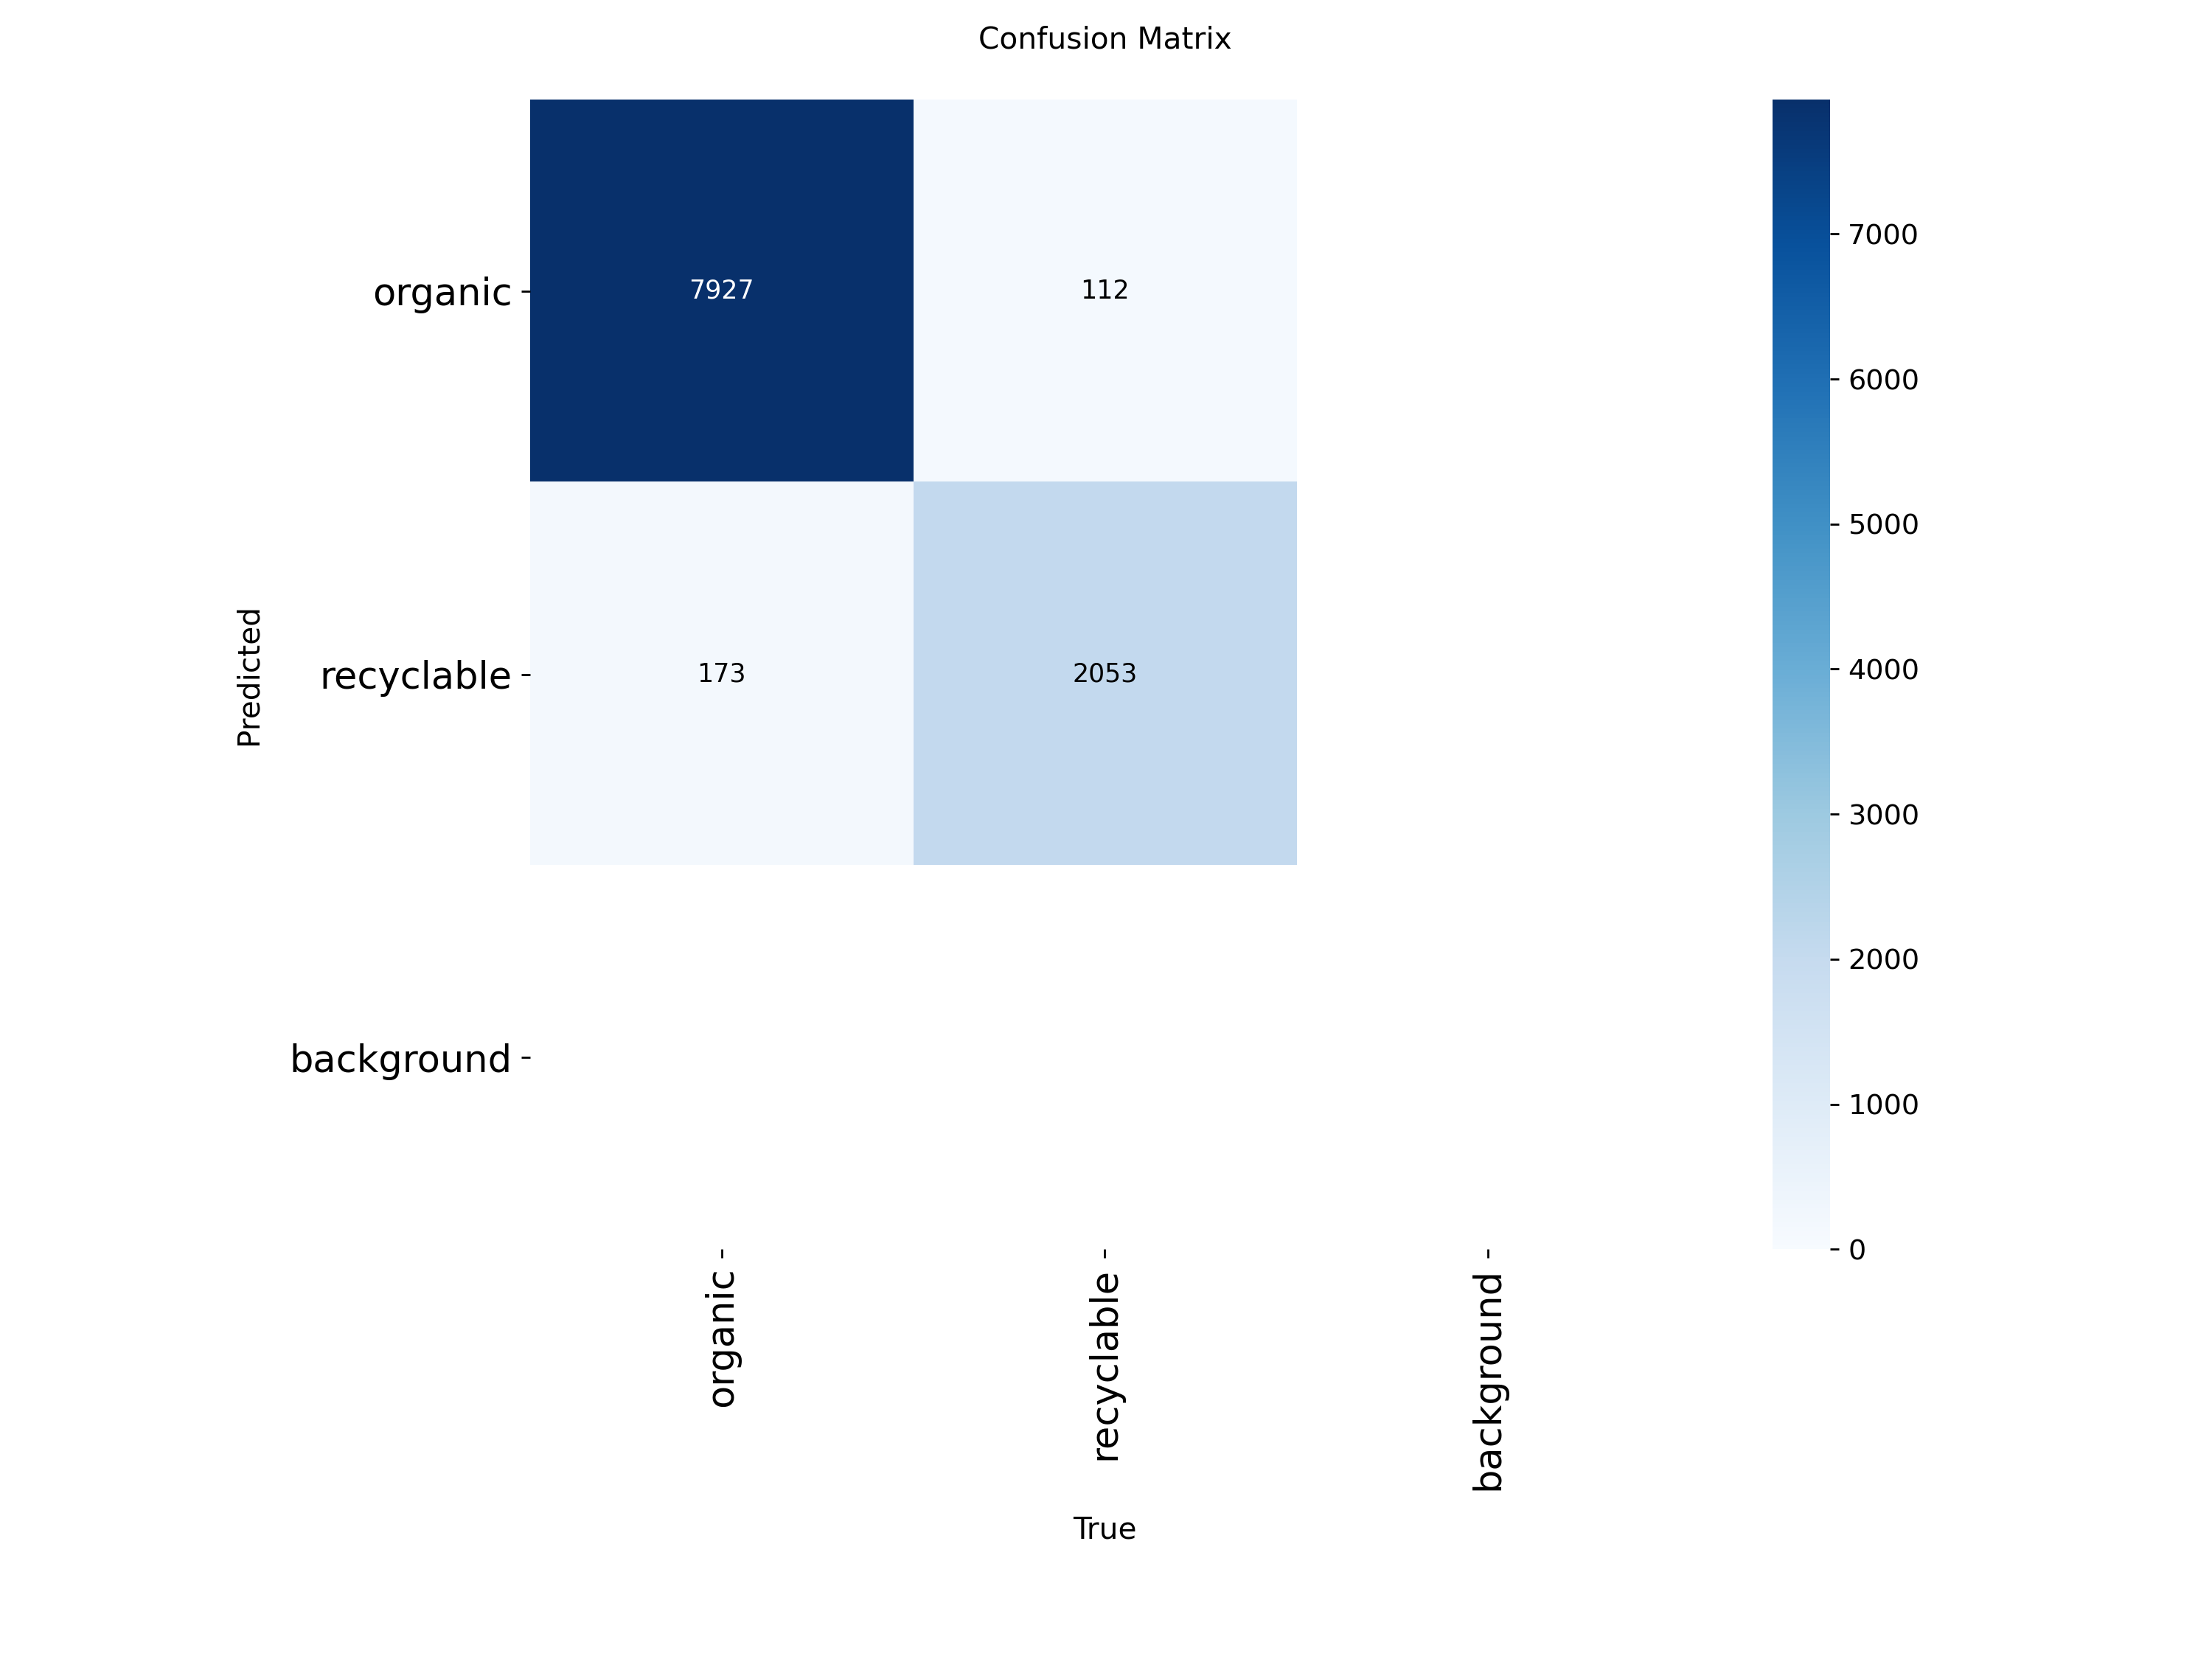

In [ ]:
Image('/content/runs/classify/train/confusion_matrix.png')

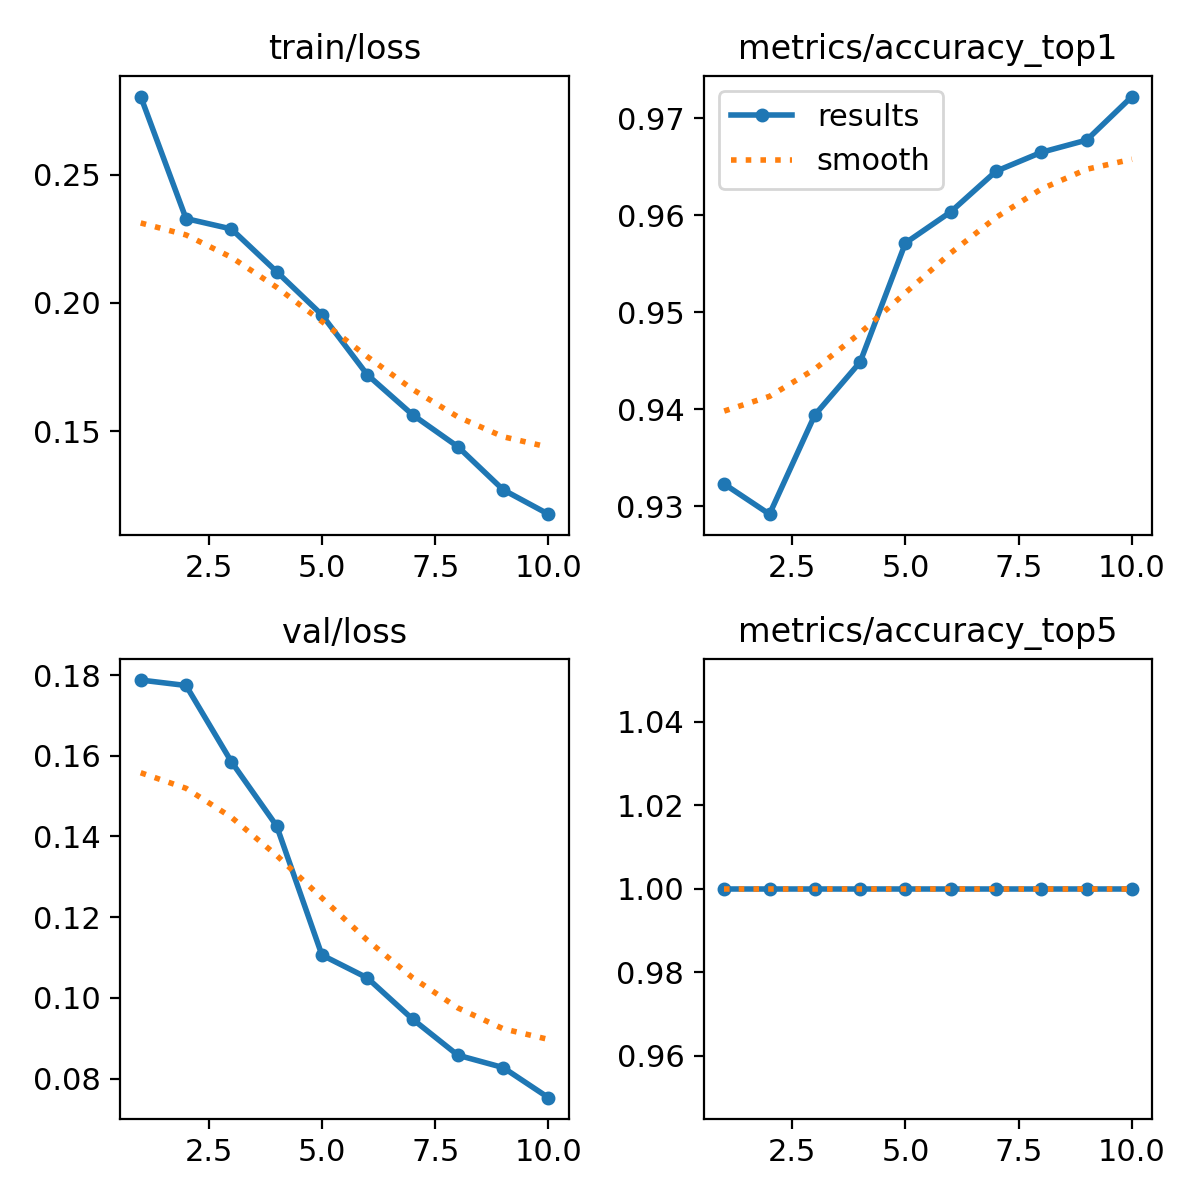

In [ ]:
Image('/content/runs/classify/train/results.png')

In [ ]:
import shutil

shutil.copy(
    '/content/runs/classify/train/weights/best.pt',
    '/content/drive/MyDrive/yolov8_cls_best.pt'
)

print("Model YOLOv8 berhasil disimpan!")

Model YOLOv8 berhasil disimpan!
